# Bucket-Partition Compaction Benchmark

This notebook compares compaction impact across three Iceberg table layouts:

| Table | Partitioning |
|---|---|
| `transactions` | None (append-only flat table) |
| `transactions_by_user_4` | `bucket(user_id, 4)` |
| `transactions_by_user_32` | `bucket(user_id, 32)` |

Flink writes one Parquet file **per bucket per checkpoint** (every 30 s). With 32 buckets that means
up to 32× more small files than the flat table for the same data volume — making compaction
proportionally more impactful.

**What this notebook measures**

1. Pre-compaction file layout for each table
2. Query performance before compaction (3-run median)
3. Compaction via `ALTER TABLE … EXECUTE optimize` run directly on the source tables
4. Post-compaction file layout and query performance
5. Side-by-side comparison: compaction speedup **and** cross-table layout effect

> **Note**: compaction rewrites files in the source tables permanently. Re-running the notebook
> after compaction will show trivial before/after differences until new small files accumulate
> (restart the Flink job or let it run for a while to rebuild the small-file backlog).

**Query suite** — chosen to highlight bucket-pruning benefit:

| Key | Why |
|---|---|
| Single-user lookup | Trino prunes to 1 bucket; most sensitive to partitioning |
| Per-user aggregation | Benefits from pre-sorted layout within buckets |
| Top-10 users by volume | GROUP BY user_id; compaction helps merge sort |
| Full-scan aggregate | Baseline — all tables should be similar |
| Filtered scan (COMPLETED) | Predicate on non-bucket column |
| Join × users (by country) | Cross-table; total I/O dominates |

**Prerequisites**: `docker compose up -d` — all services healthy.

---
## 0. Setup
---

In [3]:
import time
import statistics
import trino
import pandas as pd
from IPython.display import display

conn = trino.dbapi.connect(
    host="trino-coordinator",
    port=8080,
    user="jupyter",
    catalog="iceberg",
    schema="demo",
)

TABLES = [
    "transactions",
    "transactions_by_user_4",
    "transactions_by_user_32",
]

FULL_TABLES = {t: f"iceberg.demo.{t}" for t in TABLES}
RUNS = 3


def query(sql: str) -> pd.DataFrame:
    cur = conn.cursor()
    cur.execute(sql)
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description] if cur.description else []
    return pd.DataFrame(rows, columns=cols)


def timed_query(sql: str, runs: int = RUNS):
    """Return (median_seconds, last_result_df)."""
    times, result = [], None
    for _ in range(runs):
        t0 = time.perf_counter()
        result = query(sql)
        times.append(time.perf_counter() - t0)
    return statistics.median(times), result


def table_meta(table_key: str, suffix: str) -> str:
    """Iceberg metadata table reference."""
    return f'iceberg.demo."{table_key}${suffix}"'


# Pick a sample user_id for point-lookup queries
sample_user = query("SELECT user_id FROM iceberg.demo.transactions LIMIT 1").iloc[0]["user_id"]

print("Tables (compaction runs directly on these):")
for t in TABLES:
    n = query(f"SELECT count(*) AS n FROM iceberg.demo.{t}").iloc[0]["n"]
    print(f"  iceberg.demo.{t:<35}  {n:>10,} rows")
print(f"\nSample user for point-lookup queries: {sample_user}")
print(f"Runs per query: {RUNS}")

Tables (compaction runs directly on these):
  iceberg.demo.transactions                          1,000,000 rows
  iceberg.demo.transactions_by_user_4                1,000,000 rows
  iceberg.demo.transactions_by_user_32               1,000,000 rows

Sample user for point-lookup queries: user-031
Runs per query: 3


---
## 1. Pre-compaction row counts
---

Confirm all three source tables are populated before measuring anything.

In [4]:
print("Row counts:")
for t in TABLES:
    n = query(f"SELECT count(*) AS n FROM iceberg.demo.{t}").iloc[0]["n"]
    print(f"  iceberg.demo.{t:<35}  {n:>10,} rows")

Row counts:
  iceberg.demo.transactions                          1,000,000 rows
  iceberg.demo.transactions_by_user_4                1,000,000 rows
  iceberg.demo.transactions_by_user_32               1,000,000 rows


---
## 2. Pre-compaction file layout
---

Flink writes **one Parquet file per bucket per checkpoint**. With 32 buckets and a 30 s checkpoint
interval, `transactions_by_user_32` accumulates files 32× faster than the flat table.
This section confirms the layout we start from.

In [5]:
def file_layout_summary(table_key: str, phase: str) -> pd.DataFrame:
    m = table_meta(table_key, "files")
    df = query(f"""
        SELECT
            count(*)                                            AS file_count,
            sum(record_count)                                   AS total_records,
            round(avg(record_count), 0)                         AS avg_records_per_file,
            min(record_count)                                   AS min_records,
            max(record_count)                                   AS max_records,
            round(avg(file_size_in_bytes) / 1048576.0, 2)       AS avg_file_mb,
            round(min(file_size_in_bytes) / 1048576.0, 3)       AS min_file_mb,
            round(max(file_size_in_bytes) / 1048576.0, 2)       AS max_file_mb,
            round(sum(file_size_in_bytes) / 1048576.0, 2)       AS total_size_mb
        FROM {m}
        WHERE content = 0
    """)
    df.insert(0, "phase", phase)
    df.insert(0, "table", table_key)
    return df


def file_histogram(table_key: str) -> pd.DataFrame:
    m = table_meta(table_key, "files")
    return query(f"""
        SELECT
            CASE
                WHEN file_size_in_bytes <      128 * 1024 THEN '< 128 KB'
                WHEN file_size_in_bytes <   1 * 1048576  THEN '128 KB-1 MB'
                WHEN file_size_in_bytes <   5 * 1048576  THEN '1-5 MB'
                WHEN file_size_in_bytes <  20 * 1048576  THEN '5-20 MB'
                WHEN file_size_in_bytes <  64 * 1048576  THEN '20-64 MB'
                ELSE '>= 64 MB'
            END AS size_bucket,
            count(*)          AS file_count,
            sum(record_count) AS records
        FROM {m}
        WHERE content = 0
        GROUP BY 1
        ORDER BY min(file_size_in_bytes)
    """)


pre_layouts = {}
frames = []
for t in TABLES:
    df = file_layout_summary(t, "before")
    pre_layouts[t] = df
    frames.append(df)

print("File layout BEFORE compaction:")
display(pd.concat(frames, ignore_index=True).to_string(index=False))

print("\nFile-size histograms BEFORE compaction:")
for t in TABLES:
    print(f"\n  iceberg.demo.{t}:")
    display(file_histogram(t))

File layout BEFORE compaction:


'                  table  phase  file_count  total_records  avg_records_per_file  min_records  max_records  avg_file_mb min_file_mb max_file_mb total_size_mb\n           transactions before           1        1000000             1000000.0      1000000      1000000         5.45         5.4         5.4           5.4\n transactions_by_user_4 before           8        1000000              125000.0        80505       177244         1.01         0.7         1.4           8.1\ntransactions_by_user_32 before          52        1000000               19231.0         2503        69771         0.19         0.0         0.7           9.9'


File-size histograms BEFORE compaction:

  iceberg.demo.transactions:


,size_bucket,file_count,records
0,5-20 MB,1,1000000



  iceberg.demo.transactions_by_user_4:


,size_bucket,file_count,records
0,128 KB-1 MB,4,365359
1,1-5 MB,4,634641



  iceberg.demo.transactions_by_user_32:


,size_bucket,file_count,records
0,< 128 KB,26,128304
1,128 KB-1 MB,26,871696


---
## 3. Benchmark query definitions
---

All queries are parameterised by the full bench table name so the same suite runs against all
three tables. The **single-user lookup** is the most sensitive to bucket partitioning: Trino
can prune to a single partition file instead of scanning all data.

In [6]:
def make_benchmarks(full_table: str) -> list:
    """Return list of (key, label, sql) tuples for the given bench table."""
    return [
        (
            "single_user",
            "Single-user lookup",
            f"""
            SELECT
                count(*)              AS tx_count,
                round(sum(amount), 2) AS volume
            FROM {full_table}
            WHERE user_id = '{sample_user}'
            """,
        ),
        (
            "user_agg",
            "Per-user aggregation (all users)",
            f"""
            SELECT
                user_id,
                count(*)              AS tx_count,
                round(sum(amount), 2) AS volume
            FROM {full_table}
            GROUP BY user_id
            ORDER BY volume DESC
            """,
        ),
        (
            "top_users",
            "Top-10 users by volume",
            f"""
            SELECT
                user_id,
                count(*)              AS tx_count,
                round(sum(amount), 2) AS total
            FROM {full_table}
            GROUP BY user_id
            ORDER BY total DESC
            LIMIT 10
            """,
        ),
        (
            "full_scan_agg",
            "Full-scan aggregate",
            f"""
            SELECT
                count(*)              AS total_rows,
                round(sum(amount), 2) AS total_vol,
                round(avg(amount), 4) AS avg_amt,
                min(event_time)       AS earliest,
                max(event_time)       AS latest
            FROM {full_table}
            """,
        ),
        (
            "filtered_scan",
            "Filtered scan (status = COMPLETED)",
            f"""
            SELECT
                count(*)              AS cnt,
                round(sum(amount), 2) AS vol
            FROM {full_table}
            WHERE status = 'COMPLETED'
            """,
        ),
        (
            "join_country",
            "Join x users (volume per country)",
            f"""
            SELECT
                u.country,
                count(*)                AS tx_count,
                round(sum(t.amount), 2) AS vol
            FROM {full_table} AS t
            JOIN iceberg.demo.users AS u ON t.user_id = u.user_id
            GROUP BY u.country
            ORDER BY vol DESC
            """,
        ),
    ]


print(f"Registered {len(make_benchmarks('_'))} benchmark queries:")
for key, label, _ in make_benchmarks("_"):
    print(f"  [{key}] {label}")

Registered 6 benchmark queries:
  [single_user] Single-user lookup
  [user_agg] Per-user aggregation (all users)
  [top_users] Top-10 users by volume
  [full_scan_agg] Full-scan aggregate
  [filtered_scan] Filtered scan (status = COMPLETED)
  [join_country] Join x users (volume per country)


---
## 4. Pre-compaction benchmarks
---

In [7]:
pre_timings = {}   # {table_key: {query_key: seconds}}


In [8]:
  src = "transactions"
  full_table = FULL_TABLES[src]
  print(f"\n{'='*65}")
  print(f"  {full_table}")
  print('='*65)
  timings = {}
  for key, label, sql in make_benchmarks(full_table):
      median_s, _ = timed_query(sql)
      timings[key] = median_s
      print(f"  {label:<48}  {median_s:.3f} s")
  pre_timings[src] = timings 


  iceberg.demo.transactions
  Single-user lookup                                0.269 s
  Per-user aggregation (all users)                  0.423 s
  Top-10 users by volume                            0.292 s
  Full-scan aggregate                               0.389 s
  Filtered scan (status = COMPLETED)                0.532 s
  Join x users (volume per country)                 0.799 s


In [9]:
  # Cell 2 — transactions_by_user_4
  src = "transactions_by_user_4"
  full_table = FULL_TABLES[src]
  print(f"\n{'='*65}")
  print(f"  {full_table}")
  print('='*65)
  timings = {}
  for key, label, sql in make_benchmarks(full_table):
      median_s, _ = timed_query(sql)
      timings[key] = median_s
      print(f"  {label:<48}  {median_s:.3f} s")
  pre_timings[src] = timings 


  iceberg.demo.transactions_by_user_4
  Single-user lookup                                0.273 s
  Per-user aggregation (all users)                  0.543 s
  Top-10 users by volume                            0.443 s
  Full-scan aggregate                               0.289 s
  Filtered scan (status = COMPLETED)                0.326 s
  Join x users (volume per country)                 1.468 s


In [11]:
  # Cell 3 — transactions_by_user_32
  src = "transactions_by_user_32"
  full_table = FULL_TABLES[src]
  print(f"\n{'='*65}")
  print(f"  {full_table}")
  print('='*65)
  timings = {}
  for key, label, sql in make_benchmarks(full_table):
      median_s, _ = timed_query(sql)
      timings[key] = median_s
      print(f"  {label:<48}  {median_s:.3f} s")
  pre_timings[src] = timings 


  iceberg.demo.transactions_by_user_32
  Single-user lookup                                0.270 s
  Per-user aggregation (all users)                  0.371 s
  Top-10 users by volume                            0.276 s
  Full-scan aggregate                               0.298 s
  Filtered scan (status = COMPLETED)                0.421 s
  Join x users (volume per country)                 0.492 s


In [12]:
# Cross-table comparison BEFORE compaction
bench_keys   = [k for k, _, _ in make_benchmarks("_")]
bench_labels = {k: l for k, l, _ in make_benchmarks("_")}

print("Cross-table query times BEFORE compaction (median s):")
header = f"  {'Query':<48} {'txn':>7} {'u4':>7} {'u32':>7}"
print(header)
print('  ' + '-'*48 + ' ' + ' '.join(['-'*7]*3))
for key in bench_keys:
    vals = [f"{pre_timings[t][key]:>6.3f}s" for t in TABLES]
    print(f"  {bench_labels[key]:<48} {vals[0]} {vals[1]} {vals[2]}")

Cross-table query times BEFORE compaction (median s):
  Query                                                txn      u4     u32
  ------------------------------------------------ ------- ------- -------
  Single-user lookup                                0.269s  0.273s  0.270s
  Per-user aggregation (all users)                  0.423s  0.543s  0.371s
  Top-10 users by volume                            0.292s  0.443s  0.276s
  Full-scan aggregate                               0.389s  0.289s  0.298s
  Filtered scan (status = COMPLETED)                0.532s  0.326s  0.421s
  Join x users (volume per country)                 0.799s  1.468s  0.492s


---
## 5. Run compaction on all three bench copies
---

Trino rewrites files smaller than the target size into fewer, larger Parquet files.
Bucket-partitioned tables compact **within each bucket partition**, so the resulting
file count is bounded by the number of buckets × files-per-bucket rather than the
total file count — meaning `transactions_by_user_32` will go from many tiny files
down to 32 (one per bucket), while the flat table goes to ~1 large file.

> **Note**: compaction is CPU and memory intensive. If you see a `PAGE_TRANSPORT_TIMEOUT`
> error, increase the Trino worker's JVM heap in `docker/trino/worker/jvm.config`
> (`-Xmx`) or reduce `TARGET_MB` to compact in smaller passes.

In [13]:
TARGET_MB = 128

compact_times = {}
for src in TABLES:
    full_table = FULL_TABLES[src]
    print(f"Compacting {full_table} (target: {TARGET_MB} MB) ...")
    t0 = time.perf_counter()
    try:
        query(
            f"ALTER TABLE {full_table} EXECUTE optimize"
            f"(file_size_threshold => '{TARGET_MB}MB')"
        )
        elapsed = time.perf_counter() - t0
        compact_times[src] = elapsed
        print(f"  done in {elapsed:.1f} s")
    except Exception as e:
        compact_times[src] = None
        print(f"  FAILED after {time.perf_counter()-t0:.1f}s")
        print(f"  {type(e).__name__}: {str(e)[:300]}")

Compacting iceberg.demo.transactions (target: 128 MB) ...
  done in 0.7 s
Compacting iceberg.demo.transactions_by_user_4 (target: 128 MB) ...
  done in 4.1 s
Compacting iceberg.demo.transactions_by_user_32 (target: 128 MB) ...
  done in 3.1 s


---
## 6. Post-compaction file layout
---

In [14]:
post_layouts = {}
frames = []
for t in TABLES:
    df = file_layout_summary(t, "after")
    post_layouts[t] = df
    frames.append(df)

print("File layout AFTER compaction:")
display(pd.concat(frames, ignore_index=True).to_string(index=False))

print("\nFile count reduction:")
for t in TABLES:
    before = int(pre_layouts[t]["file_count"].iloc[0])
    after  = int(post_layouts[t]["file_count"].iloc[0])
    pct    = 100 * (1 - after / before) if before > 0 else 0
    ct     = compact_times.get(t)
    ct_str = f"{ct:.1f}s" if ct is not None else "FAILED"
    print(f"  {t:35s}: {before:4d} -> {after:4d} files  ({pct:.0f}% reduction)  compacted in {ct_str}")

print("\nBefore vs after side-by-side:")
display(pd.concat([pd.concat(list(pre_layouts.values())), pd.concat(list(post_layouts.values()))],
                  ignore_index=True).sort_values(["table", "phase"]).to_string(index=False))

print("\nFile-size histograms AFTER compaction:")
for t in TABLES:
    print(f"\n  iceberg.demo.{t}:")
    display(file_histogram(t))

File layout AFTER compaction:


'                  table phase  file_count  total_records  avg_records_per_file  min_records  max_records  avg_file_mb min_file_mb max_file_mb total_size_mb\n           transactions after           1        1000000             1000000.0      1000000      1000000         5.45         5.4         5.4           5.4\n transactions_by_user_4 after           4        1000000              250000.0       220198       279349         2.00         1.8         2.2           8.0\ntransactions_by_user_32 after          26        1000000               38462.0        19785        80051         0.38         0.2         0.8           9.9'


File count reduction:
  transactions                       :    1 ->    1 files  (0% reduction)  compacted in 0.7s
  transactions_by_user_4             :    8 ->    4 files  (50% reduction)  compacted in 4.1s
  transactions_by_user_32            :   52 ->   26 files  (50% reduction)  compacted in 3.1s

Before vs after side-by-side:


'                  table  phase  file_count  total_records  avg_records_per_file  min_records  max_records  avg_file_mb min_file_mb max_file_mb total_size_mb\n           transactions  after           1        1000000             1000000.0      1000000      1000000         5.45         5.4         5.4           5.4\n           transactions before           1        1000000             1000000.0      1000000      1000000         5.45         5.4         5.4           5.4\ntransactions_by_user_32  after          26        1000000               38462.0        19785        80051         0.38         0.2         0.8           9.9\ntransactions_by_user_32 before          52        1000000               19231.0         2503        69771         0.19         0.0         0.7           9.9\n transactions_by_user_4  after           4        1000000              250000.0       220198       279349         2.00         1.8         2.2           8.0\n transactions_by_user_4 before           8        1


File-size histograms AFTER compaction:

  iceberg.demo.transactions:


,size_bucket,file_count,records
0,5-20 MB,1,1000000



  iceberg.demo.transactions_by_user_4:


,size_bucket,file_count,records
0,1-5 MB,4,1000000



  iceberg.demo.transactions_by_user_32:


,size_bucket,file_count,records
0,128 KB-1 MB,26,1000000


In [15]:
# Recent snapshots showing the compaction commit
for t in TABLES:
    m = table_meta(t, "snapshots")
    snap_df = query(f"""
        SELECT
            committed_at,
            snapshot_id,
            operation,
            CAST(element_at(summary, 'added-data-files')   AS bigint) AS added_files,
            CAST(element_at(summary, 'removed-data-files') AS bigint) AS removed_files,
            CAST(element_at(summary, 'total-data-files')   AS bigint) AS total_files
        FROM {m}
        ORDER BY committed_at DESC
        LIMIT 4
    """)
    print(f"\nSnapshots for iceberg.demo.{t} (most recent first):")
    display(snap_df)


Snapshots for iceberg.demo.transactions (most recent first):


,committed_at,snapshot_id,operation,added_files,removed_files,total_files
0,2026-05-24 18:58:13.102000+00:00,3400078238047134893,append,1,None,1



Snapshots for iceberg.demo.transactions_by_user_4 (most recent first):


,committed_at,snapshot_id,operation,added_files,removed_files,total_files
0,2026-05-24 19:02:03.430000+00:00,7702181795540523226,replace,4.0,None,4
1,2026-05-24 18:58:30.235000+00:00,3778870507783368236,append,4.0,None,8
2,2026-05-24 18:58:01.378000+00:00,1845509899177377155,append,4.0,None,4
3,2026-05-24 18:53:14.335000+00:00,3192353307147812533,append,NaN,None,0



Snapshots for iceberg.demo.transactions_by_user_32 (most recent first):


,committed_at,snapshot_id,operation,added_files,removed_files,total_files
0,2026-05-24 19:02:06.643000+00:00,9118589816782687430,replace,26.0,None,26
1,2026-05-24 18:58:36.117000+00:00,8254355656434368165,append,26.0,None,52
2,2026-05-24 18:58:06.535000+00:00,2350324036683972641,append,26.0,None,26
3,2026-05-24 18:53:13.093000+00:00,7200001922553460102,append,NaN,None,0


---
## 7. Post-compaction benchmarks
---

In [16]:
post_timings = {}   # {table_key: {query_key: seconds}}

for src in TABLES:
    full_table = FULL_TABLES[src]
    print(f"\n{'='*65}")
    print(f"  {full_table}")
    print('='*65)
    timings = {}
    for key, label, sql in make_benchmarks(full_table):
        median_s, _ = timed_query(sql)
        timings[key] = median_s
        print(f"  {label:<48}  {median_s:.3f} s")
    post_timings[src] = timings

print("\nPost-compaction benchmarks complete.")


  iceberg.demo.transactions
  Single-user lookup                                0.321 s
  Per-user aggregation (all users)                  0.316 s
  Top-10 users by volume                            0.271 s
  Full-scan aggregate                               0.233 s
  Filtered scan (status = COMPLETED)                0.215 s
  Join x users (volume per country)                 0.699 s

  iceberg.demo.transactions_by_user_4
  Single-user lookup                                0.263 s
  Per-user aggregation (all users)                  0.320 s
  Top-10 users by volume                            0.191 s
  Full-scan aggregate                               0.163 s
  Filtered scan (status = COMPLETED)                0.172 s
  Join x users (volume per country)                 0.744 s

  iceberg.demo.transactions_by_user_32
  Single-user lookup                                0.262 s
  Per-user aggregation (all users)                  0.236 s
  Top-10 users by volume                            

---
## 8. Results
---

In [17]:
# Per-table before/after table
rows = []
for t in TABLES:
    for key, label, _ in make_benchmarks("_"):
        b = pre_timings[t].get(key)
        a = post_timings[t].get(key)
        if b is None or a is None:
            continue
        speedup = b / a if a > 0 else float("inf")
        rows.append({
            "table":          t,
            "benchmark":      label,
            "before_s":       round(b, 3),
            "after_s":        round(a, 3),
            "delta_s":        round(b - a, 3),
            "speedup_x":      round(speedup, 2),
            "improvement_pct": round(100 * (b - a) / b, 1) if b > 0 else 0,
        })

results_df = pd.DataFrame(rows)

def highlight_speedup(val):
    if isinstance(val, float):
        if val >= 2.0: return "background-color: #c6efce; color: #276221"
        if val >= 1.2: return "background-color: #ffeb9c; color: #9c6500"
        if val <  1.0: return "background-color: #ffc7ce; color: #9c0006"
    return ""

print("Per-table compaction speedup (median 3 runs):")
display(
    results_df.style
        .applymap(highlight_speedup, subset=["speedup_x"])
        .format({"before_s": "{:.3f}", "after_s": "{:.3f}",
                 "delta_s": "{:+.3f}", "speedup_x": "{:.2f}x",
                 "improvement_pct": "{:+.1f}%"})
)

Per-table compaction speedup (median 3 runs):


/tmp/ipykernel_23/1019490513.py:32: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_speedup, subset=["speedup_x"])


,table,benchmark,before_s,after_s,delta_s,speedup_x,improvement_pct
0,transactions,Single-user lookup,0.269,0.321,-0.053,0.84x,-19.7%
1,transactions,Per-user aggregation (all users),0.423,0.316,+0.106,1.34x,+25.2%
2,transactions,Top-10 users by volume,0.292,0.271,+0.021,1.08x,+7.2%
3,transactions,Full-scan aggregate,0.389,0.233,+0.156,1.67x,+40.1%
4,transactions,Filtered scan (status = COMPLETED),0.532,0.215,+0.317,2.47x,+59.6%
5,transactions,Join x users (volume per country),0.799,0.699,+0.100,1.14x,+12.5%
6,transactions_by_user_4,Single-user lookup,0.273,0.263,+0.010,1.04x,+3.7%
7,transactions_by_user_4,Per-user aggregation (all users),0.543,0.320,+0.223,1.70x,+41.0%
8,transactions_by_user_4,Top-10 users by volume,0.443,0.191,+0.251,2.32x,+56.8%
9,transactions_by_user_4,Full-scan aggregate,0.289,0.163,+0.126,1.78x,+43.7%


In [18]:
# Cross-table comparison AFTER compaction
print("Cross-table query times AFTER compaction (median s):")
header = f"  {'Query':<48} {'txn':>7} {'u4':>7} {'u32':>7}"
print(header)
print('  ' + '-'*48 + ' ' + ' '.join(['-'*7]*3))
for key in bench_keys:
    vals = [f"{post_timings[t][key]:>6.3f}s" for t in TABLES]
    print(f"  {bench_labels[key]:<48} {vals[0]} {vals[1]} {vals[2]}")

print()
print("Speedup from compaction per table:")
print(f"  {'Query':<48} {'txn':>7} {'u4':>7} {'u32':>7}")
print('  ' + '-'*48 + ' ' + ' '.join(['-'*7]*3))
for key in bench_keys:
    speedups = []
    for t in TABLES:
        b = pre_timings[t].get(key, 1)
        a = post_timings[t].get(key, 1)
        speedups.append(f"{b/a if a>0 else 0:>6.2f}x")
    print(f"  {bench_labels[key]:<48} {speedups[0]} {speedups[1]} {speedups[2]}")

Cross-table query times AFTER compaction (median s):
  Query                                                txn      u4     u32
  ------------------------------------------------ ------- ------- -------
  Single-user lookup                                0.321s  0.263s  0.262s
  Per-user aggregation (all users)                  0.316s  0.320s  0.236s
  Top-10 users by volume                            0.271s  0.191s  0.346s
  Full-scan aggregate                               0.233s  0.163s  0.214s
  Filtered scan (status = COMPLETED)                0.215s  0.172s  0.313s
  Join x users (volume per country)                 0.699s  0.744s  0.701s

Speedup from compaction per table:
  Query                                                txn      u4     u32
  ------------------------------------------------ ------- ------- -------
  Single-user lookup                                 0.84x   1.04x   1.03x
  Per-user aggregation (all users)                   1.34x   1.70x   1.57x
  Top-10 us

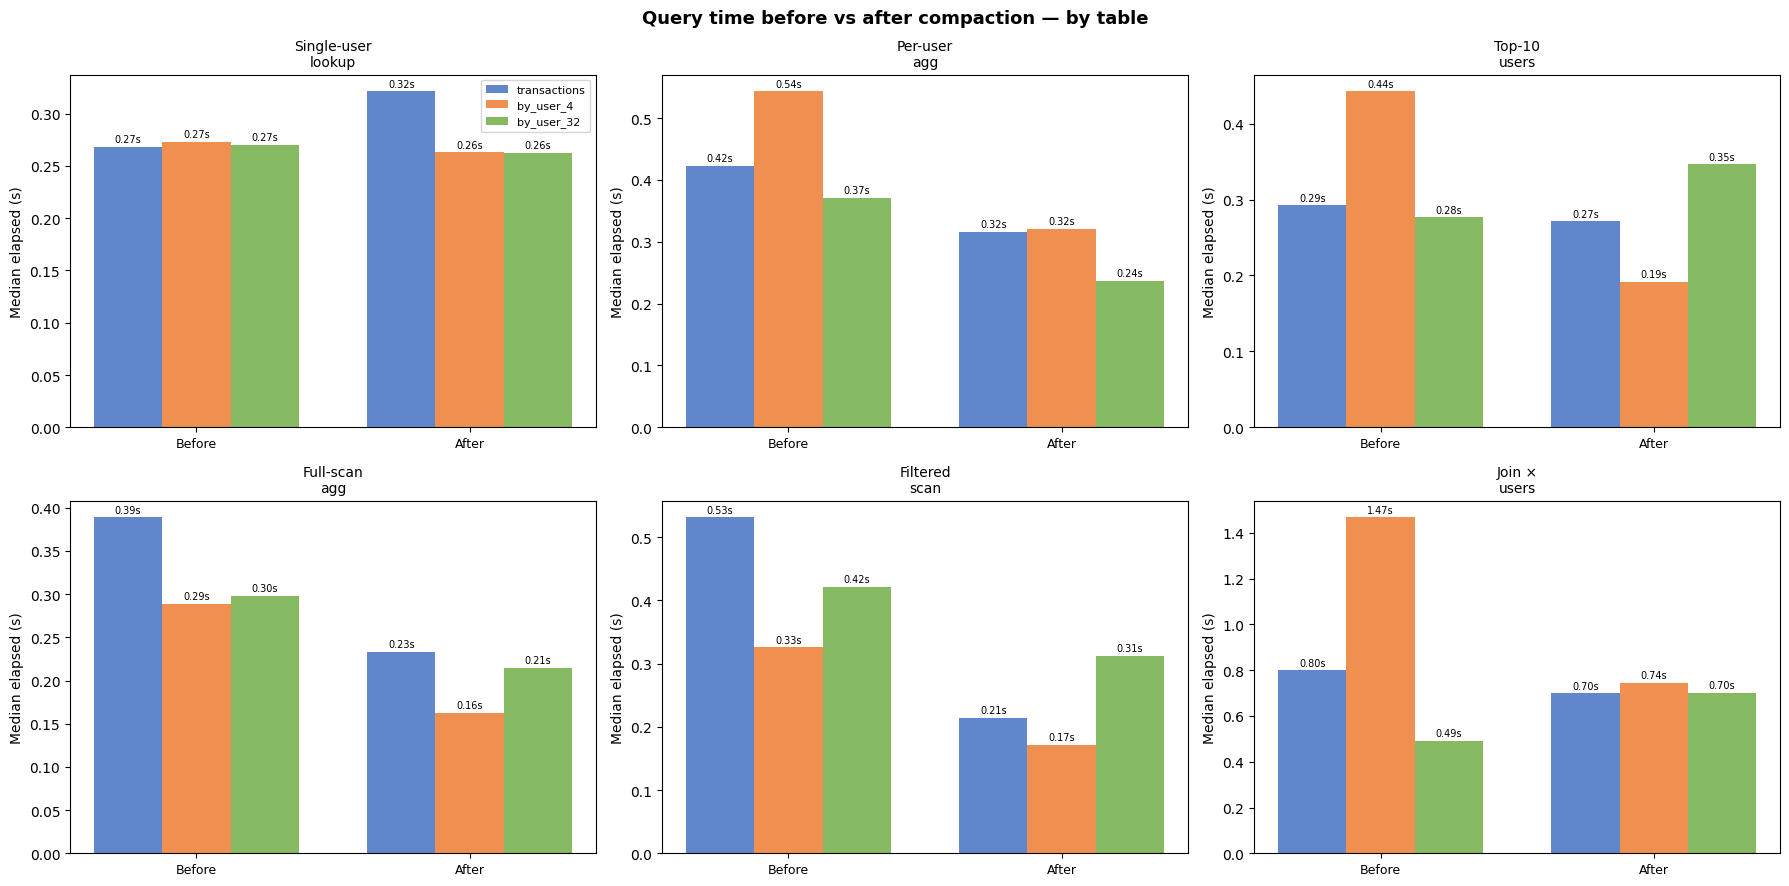

Saved: /home/jupyter/bucket_bench_before_after.png


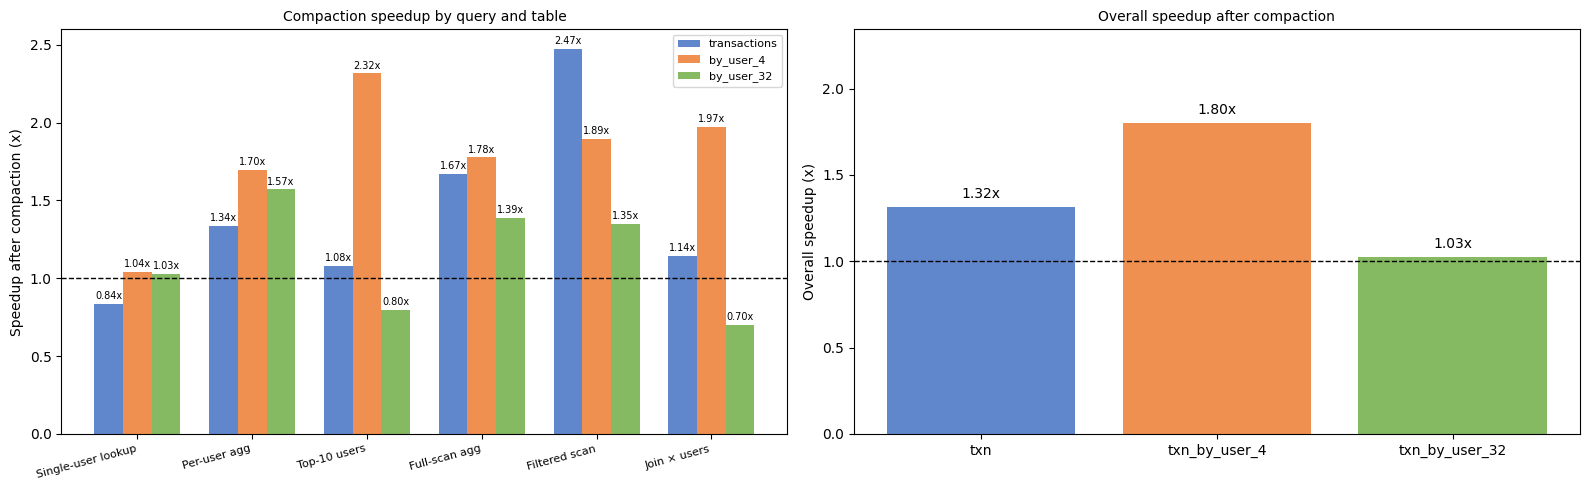

Saved: /home/jupyter/bucket_speedup_comparison.png


In [19]:
try:
    import matplotlib.pyplot as plt
    import numpy as np

    short_labels = {
        "single_user":   "Single-user\nlookup",
        "user_agg":      "Per-user\nagg",
        "top_users":     "Top-10\nusers",
        "full_scan_agg": "Full-scan\nagg",
        "filtered_scan": "Filtered\nscan",
        "join_country":  "Join ×\nusers",
    }
    table_short = ["transactions", "by_user_4", "by_user_32"]
    table_colors = ["#4472C4", "#ED7D31", "#70AD47"]

    # ── Figure 1: query times before vs after, one sub-plot per query ─────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.flatten()
    width = 0.25

    for i, key in enumerate(bench_keys):
        ax = axes[i]
        x = np.arange(2)  # before / after
        for j, (t, color) in enumerate(zip(TABLES, table_colors)):
            b = pre_timings[t].get(key, 0)
            a = post_timings[t].get(key, 0)
            offset = (j - 1) * width
            bars = ax.bar(x + offset, [b, a], width, label=table_short[j], color=color, alpha=0.85)
            ax.bar_label(bars, fmt="%.2fs", fontsize=7, padding=2)

        ax.set_xticks(x)
        ax.set_xticklabels(["Before", "After"], fontsize=9)
        ax.set_ylabel("Median elapsed (s)")
        ax.set_title(short_labels.get(key, key), fontsize=10)
        if i == 0:
            ax.legend(fontsize=8)

    plt.suptitle("Query time before vs after compaction — by table", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/home/jupyter/bucket_bench_before_after.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: /home/jupyter/bucket_bench_before_after.png")

    # ── Figure 2: speedup comparison across tables ─────────────────────────────
    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

    # Left: grouped speedup bars (query × table)
    ax = axes2[0]
    x = np.arange(len(bench_keys))
    for j, (t, color) in enumerate(zip(TABLES, table_colors)):
        speedups = []
        for key in bench_keys:
            b = pre_timings[t].get(key, 1)
            a = post_timings[t].get(key, 1)
            speedups.append(b / a if a > 0 else 1.0)
        offset = (j - 1) * width
        bars = ax.bar(x + offset, speedups, width, label=table_short[j], color=color, alpha=0.85)
        ax.bar_label(bars, fmt="%.2fx", fontsize=7, padding=2)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([short_labels.get(k, k).replace("\n", " ") for k in bench_keys],
                       rotation=15, ha="right", fontsize=8)
    ax.set_ylabel("Speedup after compaction (x)")
    ax.set_title("Compaction speedup by query and table", fontsize=10)
    ax.legend(fontsize=8)

    # Right: overall speedup per table
    ax2 = axes2[1]
    overall_speedups = []
    overall_labels   = []
    colors_bar       = []
    for t, color in zip(TABLES, table_colors):
        sum_b = sum(pre_timings[t][k]  for k in bench_keys)
        sum_a = sum(post_timings[t][k] for k in bench_keys)
        overall_speedups.append(sum_b / sum_a if sum_a > 0 else 1.0)
        overall_labels.append(t.replace("transactions", "txn"))
        colors_bar.append(color)
    bars2 = ax2.bar(overall_labels, overall_speedups, color=colors_bar, alpha=0.85)
    ax2.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax2.bar_label(bars2, fmt="%.2fx", fontsize=10, padding=4)
    ax2.set_ylabel("Overall speedup (x)")
    ax2.set_title("Overall speedup after compaction", fontsize=10)
    ax2.set_ylim(0, max(overall_speedups) * 1.3)

    plt.tight_layout()
    plt.savefig("/home/jupyter/bucket_speedup_comparison.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: /home/jupyter/bucket_speedup_comparison.png")

except ImportError:
    print("matplotlib not installed — skipping charts.")

In [20]:
SEP = "=" * 80
print(SEP)
print("  BUCKET-PARTITION COMPACTION BENCHMARK — SUMMARY")
print(SEP)

print(f"\n  {'Table':35s}  {'Files (before→after)':22s}  {'Compact time':12s}")
print(f"  {'-'*35}  {'-'*22}  {'-'*12}")
for t in TABLES:
    before = int(pre_layouts[t]["file_count"].iloc[0])
    after  = int(post_layouts[t]["file_count"].iloc[0])
    pct    = 100 * (1 - after / before) if before > 0 else 0
    ct     = compact_times.get(t)
    ct_str = f"{ct:.1f}s" if ct is not None else "FAILED"
    print(f"  {t:35s}  {before:5d} -> {after:5d}  ({pct:.0f}%)".ljust(60) + f"  {ct_str:>12}")

print()
col_w = 8
print(f"  {'Benchmark':<48}", end="")
for t in TABLES:
    short = t.replace("transactions_by_user_", "u").replace("transactions", "txn")
    print(f"  {short+' B':>{col_w}} {short+' A':>{col_w}} {'spd':>{col_w}}", end="")
print()
print("  " + "-"*48 + ("  " + "-"*col_w + " " + "-"*col_w + " " + "-"*col_w) * 3)

for key, label, _ in make_benchmarks("_"):
    print(f"  {label:<48}", end="")
    for t in TABLES:
        b = pre_timings[t].get(key, 0)
        a = post_timings[t].get(key, 0)
        spd = b / a if a > 0 else 0
        print(f"  {b:>{col_w}.3f} {a:>{col_w}.3f} {spd:>{col_w}.2f}x", end="")
    print()

print()
print(f"  {'Overall':48s}", end="")
for t in TABLES:
    sum_b = sum(pre_timings[t].values())
    sum_a = sum(post_timings[t].values())
    spd   = sum_b / sum_a if sum_a > 0 else 0
    print(f"  {sum_b:>{col_w}.3f} {sum_a:>{col_w}.3f} {spd:>{col_w}.2f}x", end="")
print()
print(SEP)

  BUCKET-PARTITION COMPACTION BENCHMARK — SUMMARY

  Table                                Files (before→after)    Compact time
  -----------------------------------  ----------------------  ------------
  transactions                             1 ->     1  (0%)           0.7s
  transactions_by_user_4                   8 ->     4  (50%)          4.1s
  transactions_by_user_32                 52 ->    26  (50%)          3.1s

  Benchmark                                            txn B    txn A      spd      u4 B     u4 A      spd     u32 B    u32 A      spd
  ------------------------------------------------  -------- -------- --------  -------- -------- --------  -------- -------- --------
  Single-user lookup                                   0.269    0.321     0.84x     0.273    0.263     1.04x     0.270    0.262     1.03x
  Per-user aggregation (all users)                     0.423    0.316     1.34x     0.543    0.320     1.70x     0.371    0.236     1.57x
  Top-10 users by volume 

---
## 9. Notes on re-running
---

Because compaction ran directly on the source tables, there is nothing to drop or reset here.

To get a meaningful before/after measurement on the next run:

1. Let the Flink job accumulate new small files (wait several minutes / checkpoints).
2. Re-run from section **2** (file layout) onwards — the setup cell in section 0 is idempotent.

In [ ]:
print("Nothing to clean up — compaction ran on the source tables directly.")
print("Re-run from section 2 after new small files have accumulated.")